In [1]:
%cd /home/qid/MMMM

/home/qid/MMMM


In [2]:
import sys
sys.path.append("./models")
sys.path.append("./training")
sys.path.append("./testing")
sys.path.append("./utils")
sys.path.append("./ZuCo")
sys.path.append("./trainer")

In [3]:
# Import Pytorch
import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter

# Import Pretrain Libraries (transformers + diffusers)
from transformers import BartTokenizer
from diffusers import AutoencoderKL

# Parallel Helper
from parallel import DataParallelModel, DataParallelCriterion

# Import Our Own Functions
from master_init import *
from DSG import *

from count_params import count_params

# Import Tasks
import EEG_TEXT_BART
import EEG_TEXT_BART_SENTIMENT
import EEG_IMG_DIFFUSION
import EEG_IMG_CLASSIFICATION
import PRETRAIN_EEG_IMG_CLIP_MATCHING
import PRETRAIN_EEG_TEXT_CLIP_MATCHING

In [4]:
torch.set_default_dtype(torch.float32)

# config = get_config() Implement later
config = {
    "device" : "cuda",
    "device_ids" : [0,1,2,3],
    "staging_device" : "cuda",
    "num_epochs" : 100,
    "use_non_pytorch_parallel" : False,
    "test_run" : False,
    "live_evaluate" : True,
    "eval_interval" : 1,
    "log_dir" : "./logs"
}

device = config["device"]
device_ids = config["device_ids"]
staging_device = config["staging_device"]
num_epochs = config["num_epochs"]
use_non_pytorch_parallel = config["use_non_pytorch_parallel"]
test_run = config["test_run"]
live_evaluate = config["live_evaluate"]
eval_interval = config["eval_interval"]
log_dir = config["log_dir"]

In [5]:
model = INITIALIZE_MODEL(device=None, device_ids=device_ids, dtype=torch.float32)
if use_non_pytorch_parallel:
    model = DataParallelModel(model).to(device)
else:
    model = nn.DataParallel(model, device_ids=device_ids).to(device)
dataset_dict = INITIALIZE_DATALOADERS(
    keys=["ZuCo-BART", "ZuCo-CLIP", "Brain2Image"],
    bsz=[256, 256, 1],
    dev_bsz=[256, 256, 1]
)

LOADED EEG ENCODER
LOADED CLIP ENCODER
LOADED BART MODEL
LOADED EEG-TEXT-BART
LOADED U-NET
LOADED CLIP TOKENIZER
LOADED EEG-IMG-DIFFUSION
LOADED EEG-IMG-CLASSIFICATION
LOADED EEG-TEXT-SENTIMENT


In [6]:
args_dict = {
    "model" : model,
    "dataloader" : dataset_dict["ZuCo-CLIP"],
    "optimizer" : optim.Adam(model.parameters(), lr=5e-3),
    "criterion" : nn.CrossEntropyLoss(),
    "device" : device,
    "device_ids" : device_ids,
    "staging_device" : staging_device,
#     "temperature" : 20
}

In [7]:
BART_tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")

In [8]:
dataloader = args_dict["dataloader"]
model = args_dict["model"]
tokenizer = BART_tokenizer
optimizer = args_dict["optimizer"]
criterion = args_dict["criterion"]
device = args_dict["device"] if "device" in args_dict else "cuda"
device_ids = args_dict["device_ids"] if "device_ids" in args_dict else None
staging_device = args_dict["staging_device"] if "staging_device" in args_dict else None
bsz = args_dict["bsz"] if "bsz" in args_dict else 64
temperature = 0.04

In [9]:
dataloader["train"].set_bsz(bsz)
current_data = dataloader["train"].load_data()

In [10]:
input_embeddings, seq_len, input_masks, input_mask_invert, target_ids, target_mask, sentiment_labels, sent_level_EEG = current_data["data"]
good = []
for i in range(len(sentiment_labels)):
    if not sentiment_labels[i] == -100:
        good.append(i)

input_embeddings = input_embeddings[good]
input_masks = input_masks[good]
input_mask_invert = input_mask_invert[good]
target_ids = target_ids[good]
sentiment_labels = sentiment_labels[good]

target = torch.zeros(input_embeddings.shape[0], 3).to(device)
for i in range(input_embeddings.shape[0]):
    target[i][sentiment_labels[i]] = 1.0

input_embeddings_batch = input_embeddings.to(staging_device, dtype=torch.float32)
input_masks_batch = input_masks.to(staging_device, dtype=torch.float32)
input_mask_invert_batch = input_mask_invert.to(staging_device, dtype=torch.float32)
target_ids_batch = target_ids.to(staging_device)

"""replace padding ids in target_ids with -100"""
target_ids_batch[target_ids_batch == tokenizer.pad_token_id] = -100

optimizer.zero_grad()

args_dict = {
    "input_data_batch" : input_embeddings_batch,
    "input_masks_batch" : input_masks_batch,
    "input_masks_invert" : input_mask_invert_batch,
    "target_ids_batch" : target_ids_batch,
    "pool_result" : True,
    "temperature" : temperature
    }

output = model(
    mode="EEG-TEXT-BART-SENTIMENT",
    args_dict=args_dict,
    staging_device=staging_device
    )

In [12]:
dataloader["train"].set_bsz(bsz)
current_data = dataloader["train"].load_data()

In [13]:
optimizer.zero_grad()

In [14]:
max_len = max(i.shape[0] for i in current_data["data"])
eegs = []
masks = []
invert_masks = []

for i in range(len(current_data["data"])):
    eeg = current_data["data"][i]
    cur_sz = eeg.shape[0]
    mask = torch.cat((torch.ones(cur_sz), torch.zeros(max_len - cur_sz)))
    masks.append(mask)
    invert_masks.append(1 - mask)
    eegs.append(torch.cat((eeg, torch.zeros(max_len - cur_sz, eeg.shape[1]))))

eeg_batch = torch.stack(eegs)
masks_batch = torch.stack(masks)
invert_masks_batch = torch.stack(invert_masks)

args_dict = {
    "input_data_batch" : eeg_batch,
    "input_masks_batch" : masks_batch,
    "input_masks_invert" : invert_masks_batch,
    "pool_result" : True,
    "temperature" : temperature
}

output = model(
    mode="EEG-IMG-BRAIN2IMAGE-CLASSIFICATION",
    args_dict=args_dict,
    staging_device=staging_device
    )

expected = current_data["classes"]

target = torch.zeros(len(eegs), 40).to(device, dtype=torch.float32)
for i in range(len(expected)):
    target[i][expected[i]] = 1.0

loss = criterion(output.to(dtype=torch.float32), target.to(dtype=torch.float32))

RuntimeError: Tensors must have same number of dimensions: got 3 and 2

In [28]:
# torch.max(output[0])

tensor(0.0663, device='cuda:0', grad_fn=<MaxBackward1>)

In [12]:
# np_output = output.detach().cpu().numpy()

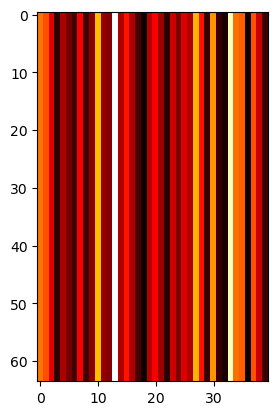

In [13]:
# # import matplotlib.pyplot as plt

# plt.imshow(np_output, cmap='hot', interpolation='nearest')
# plt.show()

In [14]:
expected_output = target.detach().cpu().numpy()

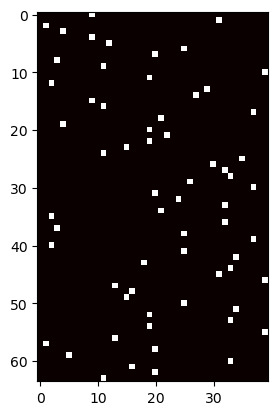

In [15]:
plt.imshow(expected_output, cmap='hot', interpolation='nearest')
plt.show()

In [16]:
# BART_tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")

In [17]:
# args_dict = {
#         "model" : model,
#         "dataloader" : dataset_dict["ZuCo-CLIP"],
#         "optimizer" : optim.Adam(model.parameters(), lr=1e-5),
#         "tokenizer" : BART_tokenizer,
#         "criterion" : nn.KLDivLoss(reduction="batchmean"),
#         "device" : device,
#         "device_ids" : device_ids,
#         "staging_device" : staging_device,
#         "dev_bsz" : 256,
#         "bool_eval" : True
#     }

In [18]:
# dataloader = args_dict["dataloader"]
# model = args_dict["model"]
# optimizer = args_dict["optimizer"]
# tokenizer = args_dict["tokenizer"]
# criterion = args_dict["criterion"]
# device = args_dict["device"] if "device" in args_dict else "cuda"
# device_ids = args_dict["device_ids"] if "device_ids" in args_dict else None
# staging_device = args_dict["staging_device"] if "staging_device" in args_dict else None
# dev_bsz = args_dict["dev_bsz"] if "dev_bsz" in args_dict else 64
# bool_eval = args_dict["bool_eval"] if "bool_eval" in args_dict else False
# symmetric_KL = lambda a, b, t=1: 0.5 * (criterion(F.log_softmax(a/t, dim=1), F.softmax(b/t, dim=1)) + criterion(F.log_softmax(b/t, dim=1), F.softmax(a/t, dim=1)))
# temperature = args_dict["temperature"] if "temperature" in args_dict else 0.07

In [19]:
# current_data = dataloader["train"].load_data()

In [20]:
# input_embeddings, seq_len, input_masks, input_mask_invert, target_ids, target_mask, sentiment_labels, sent_level_EEG = current_data["data"]

# input_embeddings_batch = input_embeddings
# input_masks_batch = input_masks
# input_mask_invert_batch = input_mask_invert
# target_ids_batch = target_ids

# """replace padding ids in target_ids with -100"""
# target_ids_batch[target_ids_batch == tokenizer.pad_token_id] = -100

# optimizer.zero_grad()

# args_dict = {
#     "input_data_batch" : input_embeddings_batch.to(staging_device, dtype=torch.float32),
#     "input_masks_batch" : input_masks_batch.to(staging_device, dtype=torch.float32),
#     "input_masks_invert" : input_mask_invert_batch.to(staging_device, dtype=torch.float32),
#     "target_ids_batch" : target_ids_batch.to(staging_device),
#     "pool_result" : False
#     }

# output = model(
#     mode="PRETRAIN-EEG-TEXT-CLIP-MATCHING",
#     args_dict=args_dict,
#     staging_device=staging_device,
# )

In [21]:
# target_embed = current_data["target"].to(torch.float32)
# target_embeds_pooled = torch.mean(target_embed, dim=1)
# target_pairwise_embeds = torch.mm(target_embeds_pooled, target_embeds_pooled.T)

# output = torch.mean(output, dim=1).to(torch.float32)
# output = torch.mm(output, target_embeds_pooled.T)

In [22]:
# new_output = F.softmax(output/temperature, dim=1)

In [23]:
# new_output

In [24]:
np_output = output.detach().cpu().numpy()

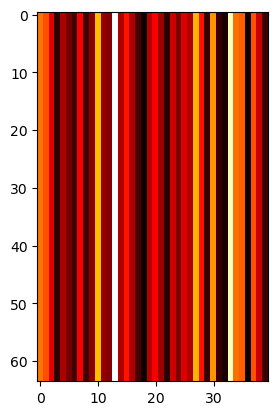

In [25]:
import matplotlib.pyplot as plt

plt.imshow(np_output, cmap='hot', interpolation='nearest')
plt.show()

In [26]:
temp = 20

In [27]:
new_target = F.softmax(target_pairwise_embeds/temp, dim=1)
np_target = new_target.detach().cpu().numpy()

NameError: name 'target_pairwise_embeds' is not defined

In [ ]:
new_target.shape

In [ ]:
new_target[:4,:4]

In [ ]:
plt.imshow(np_target, cmap='hot', interpolation='nearest')
plt.show()

In [ ]:
[np_target[i][i] for i in range(256)]